<div style="border:solid green 2px; padding: 20px">
<b>Iteration - 1</b><br>
<b>Reviewer’s comments</b><br>

Hello Ivey!,
  
I am Alexangel, your reviewer in this first iteration,
  
Another project successfully completed - well done! 🏆 Your consistent effort and progress are truly commendable.

Our team is here to help you keep pushing forward and honing your skills as you advance through the program.

My comments are marked as `Reviewer's comment`. You can contact me via Tripleten Hub for further feedback. This information is described below.

**What Was Great**:
- Excellent job on following the structure of the project.
- Your attempt at outlining the work plan shows promise.

**Tips for Future Projects**:
- Consider adding brief comments after the analysis or graph of every dataframe to make your work even more integral.

</div>

-------------------------------------------------------------------------------------------------------------

***Name of the reviewer***: Alexangel Bracho

***Reviewer’s Tripleten Hub link*** : [reviewer's link](https://hub.tripleten.com/u/6b1cbe37)

-------------------------------------------------------------------------------------------------------------

```
The telecom operator Interconnect would like to be able to forecast their churn of clients. If it's discovered that a user is planning to leave, they will be offered promotional codes and special plan options. Interconnect's marketing team has collected some of their clientele's personal data, including information about their plans and contracts.

Interconnect's services
Interconnect mainly provides two types of services:

Landline communication. The telephone can be connected to several lines simultaneously.
Internet. The network can be set up via a telephone line (DSL, digital subscriber line) or through a fiber optic cable.
Some other services the company provides include:

Internet security: antivirus software (DeviceProtection) and a malicious website blocker (OnlineSecurity)
A dedicated technical support line (TechSupport)
Cloud file storage and data backup (OnlineBackup)
TV streaming (StreamingTV) and a movie directory (StreamingMovies)
The clients can choose either a monthly payment or sign a 1- or 2-year contract. They can use various payment methods and receive an electronic invoice after a transaction.

Data Description
The data consists of files obtained from different sources:

contract.csv — contract information
personal.csv — the client's personal data
internet.csv — information about Internet services
phone.csv — information about telephone services
In each file, the column customerID contains a unique code assigned to each client.

The contract information is valid as of February 1, 2020.
```

<div class="alert alert-block alert-success">
<b>Reviewer's comment</b> <a class="tocSkip"></a>

Good introduction.

</div>

# Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Data Cleaning

In [2]:
#Load Data
path1 = '/datasets/final_provider/' + 'contract.csv'
path2 = '/datasets/final_provider/' + 'personal.csv'
path3 = '/datasets/final_provider/' + 'internet.csv'
path4 = '/datasets/final_provider/' + 'phone.csv'

contract_data = pd.read_csv(path1)
client_data =  pd.read_csv(path2)
ip_data = pd.read_csv(path3) #ip = internet plan
pp_data = pd.read_csv(path4) #pp = phone plan

#Check Variables
print('Contract Data')
print(contract_data.head(2))
print('-------------------------------------------------------------------------')
print('Client Data')
print(client_data.head(2))
print('-------------------------------------------------------------------------')
print('Internet Plan Data')
print(ip_data.head(2))
print('-------------------------------------------------------------------------')
print('Phone Plan Data')
print(pp_data.head(2))
print('-------------------------------------------------------------------------')
print('''It Seems All The The CustomerIDs Are Lining Up Except For When It Comes To Phone Plan Data
Lets Print Out The Second Row To See What's Happening
Looks Like Phone Plan Data Is Lagging One Behind Which Leads Me To Be Believe The The 1st True CustomerID Is Actually The Last''')
print(pp_data.tail(1))
print('''Looks Like It's Not There
We Will Have To Find It Manually''')
lost_customer = pp_data[pp_data['customerID'] == '7590-VHVEG']
print(lost_customer)
print("Doesn't Exist")
print('Check Distribution Of No And Yes For MultipleLines')
print(pp_data['MultipleLines'].value_counts())

Contract Data
   customerID   BeginDate EndDate            Type PaperlessBilling  \
0  7590-VHVEG  2020-01-01      No  Month-to-month              Yes   
1  5575-GNVDE  2017-04-01      No        One year               No   

      PaymentMethod  MonthlyCharges TotalCharges  
0  Electronic check           29.85        29.85  
1      Mailed check           56.95       1889.5  
-------------------------------------------------------------------------
Client Data
   customerID  gender  SeniorCitizen Partner Dependents
0  7590-VHVEG  Female              0     Yes         No
1  5575-GNVDE    Male              0      No         No
-------------------------------------------------------------------------
Internet Plan Data
   customerID InternetService OnlineSecurity OnlineBackup DeviceProtection  \
0  7590-VHVEG             DSL             No          Yes               No   
1  5575-GNVDE             DSL            Yes           No              Yes   

  TechSupport StreamingTV StreamingMovie

In [3]:
print('Shape Of All Four Data Frames')
print(f'Contract Data Shape {contract_data.shape}')
print(f'Client Data Shape {client_data.shape}')
print(f'Internet Plan Data Shape {ip_data.shape}')
print(f'Phone Plan Data Shape {pp_data.shape}')
print('Lets Join All Our Dataframes By customerID And See What Kind Of Shape We Get')
df = contract_data.copy()
df = df.merge(client_data, on='customerID', how='left', validate='one_to_one')
df = df.merge(ip_data, on='customerID', how='left', validate='one_to_one')
df = df.merge(pp_data, on='customerID', how='left', validate='one_to_one')
print(f'Merged DataFrame Shape {df.shape}')
('Check Columns')
print(df.head(1))
print('Sanity Check On Duplicated Rows')
duplicated = df.duplicated()
print(duplicated.value_counts())
print('Check Data Types And Missing Values')
print(df.info())
print('----------------------------------------------')
print('Check Catgory Split Of Non Yes/No Columns')
df = df.rename(columns={
    'gender': 'Gender'
})
print(f" Gender {df['Gender'].unique()}")
print(f"Payment Method {df['PaymentMethod'].unique()}")
print(f"Type Of Commitment {df['Type'].unique()}")
print(f"Internet Service {df['InternetService'].unique()}")
print('----------------------------------------------------')
print("Fill 'nan' From Internet Service Wtih 'No Internet'")
print("""Then Categorize All Columns Appropriately
Convert Dates To DateTime And 'TotalCharges' To Float'""")
df['InternetService'] = df['InternetService'].fillna('No Internet')
print(f"Internet Sanity Check {df['InternetService'].unique()}")
#Convert 'TotalCharges' To Float
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
#Convert 'BeginDate' And 'EndDate' To Datetime
date_list = ['BeginDate', 'EndDate']
for i in date_list:
    df[i] = pd.to_datetime(df[i], errors='coerce')
#Fill Back No Values That Went NaN Back To No
#df['EndDate'] = df['EndDate'].fillna('No')
#Create Order For Ordinal Encoding
contract_order = {
    'Month-to-month': 0,
    'One year': 1,
    'Two year': 2
}
df['Type'] = df['Type'].map(contract_order)

ordinal_cols = ['Type']

#Create Seperate Copy For EDA
eda_df = df.copy()
#Create List For All Columns We Want To Use One Hot Encoding For
cat_cols = df.select_dtypes(include='object').columns.to_list()
cat_cols = [col for col in cat_cols if col not in ordinal_cols and col != 'customerID']
print(len(cat_cols))
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print('----------------------------------------------------------')
print("Data Types, Encoding, & NaN Values Inside 'TotalCharges' Sanity Check")
print(df.dtypes)
print(df.head(5))
print(f"Null Count In TotalCharges: {df['TotalCharges'].isnull().sum()}")

Shape Of All Four Data Frames
Contract Data Shape (7043, 8)
Client Data Shape (7043, 5)
Internet Plan Data Shape (5517, 8)
Phone Plan Data Shape (6361, 2)
Lets Join All Our Dataframes By customerID And See What Kind Of Shape We Get
Merged DataFrame Shape (7043, 20)
   customerID   BeginDate EndDate            Type PaperlessBilling  \
0  7590-VHVEG  2020-01-01      No  Month-to-month              Yes   

      PaymentMethod  MonthlyCharges TotalCharges  gender  SeniorCitizen  \
0  Electronic check           29.85        29.85  Female              0   

  Partner Dependents InternetService OnlineSecurity OnlineBackup  \
0     Yes         No             DSL             No          Yes   

  DeviceProtection TechSupport StreamingTV StreamingMovies MultipleLines  
0               No          No          No              No           NaN  
Sanity Check On Duplicated Rows
False    7043
dtype: int64
Check Data Types And Missing Values
<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entri

In [4]:
print('Create Target Column')
eda_df['Loyalty'] = df['EndDate'].notna().astype(int)
print(eda_df['Loyalty'].head(5))
print('Sanity Check')
print(eda_df['EndDate'].head(5))

Create Target Column
0    0
1    0
2    1
3    0
4    1
Name: Loyalty, dtype: int64
Sanity Check
0          NaT
1          NaT
2   2019-12-01
3          NaT
4   2019-11-01
Name: EndDate, dtype: datetime64[ns]


# EDA

In [5]:
print('Time Window When It Comes To Beginning Membership With Company')
print(eda_df['BeginDate'].min())
print(eda_df['BeginDate'].max())

#Create Target Column For EDA DF
eda_df['Loyalty'] = df['EndDate'].notna().astype(int)

print('Average Churn Rate When It Comes To Contract Type')
avgchurn_contract = eda_df.groupby('Type')['Loyalty'].mean()
print(avgchurn_contract)
print('Average Churn Rate When It Comes To Payment Method')
avgchurn_payment = eda_df.groupby('PaymentMethod')['Loyalty'].mean()
print(avgchurn_payment)
print('Average Chrun Rate For Combination Of Contract And Payment Methods')
avgchurn_cp = eda_df.groupby(['Type', 'PaymentMethod'])['Loyalty'].mean()
print(avgchurn_cp)
print('Sanity Check')
print(eda_df.head(1))

print('Balance Of Chrun Data')
print(eda_df['Loyalty'].value_counts())


Time Window When It Comes To Beginning Membership With Company
2013-10-01 00:00:00
2020-02-01 00:00:00
Average Churn Rate When It Comes To Contract Type
Type
0    0.427097
1    0.112695
2    0.028319
Name: Loyalty, dtype: float64
Average Churn Rate When It Comes To Payment Method
PaymentMethod
Bank transfer (automatic)    0.167098
Credit card (automatic)      0.152431
Electronic check             0.452854
Mailed check                 0.191067
Name: Loyalty, dtype: float64
Average Chrun Rate For Combination Of Contract And Payment Methods
Type  PaymentMethod            
0     Bank transfer (automatic)    0.341256
      Credit card (automatic)      0.327808
      Electronic check             0.537297
      Mailed check                 0.315789
1     Bank transfer (automatic)    0.097187
      Credit card (automatic)      0.103015
      Electronic check             0.184438
      Mailed check                 0.068249
2     Bank transfer (automatic)    0.033688
      Credit card (automatic

Now We Are Going To Check The Distribution Of Loyal And Non Loyal Customers Over The Years
Based On Payment Method
When Isolated, Autmatic Payments Did Best
But When Grouped By Contract
Mailed Checks Outperform All Other Payment Methods


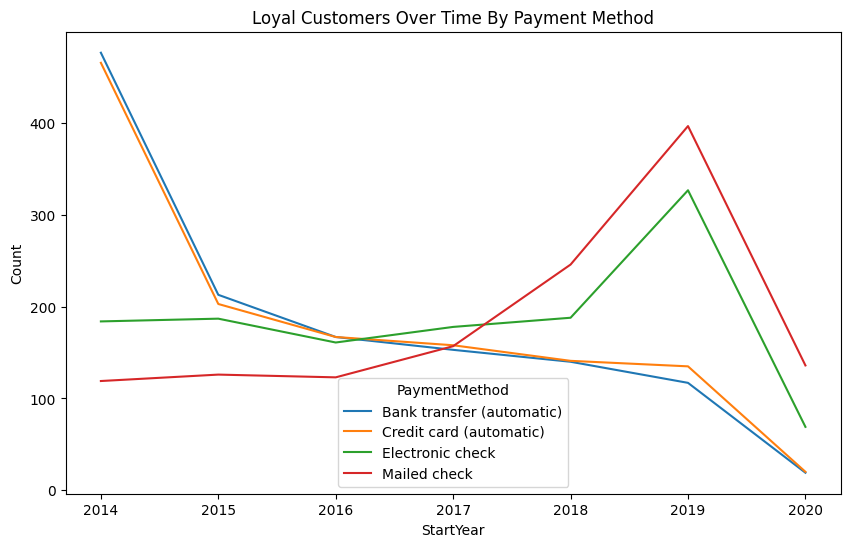

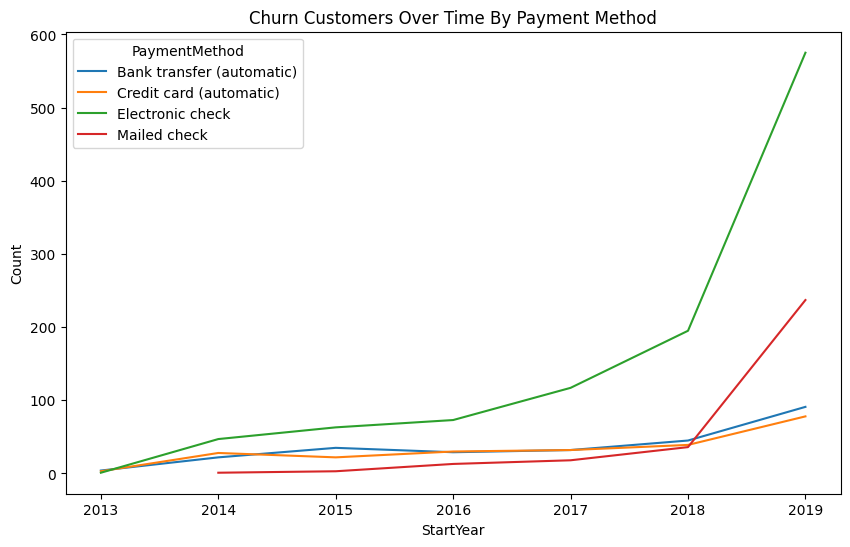

In [6]:
print("""Now We Are Going To Check The Distribution Of Loyal And Non Loyal Customers Over The Years
Based On Payment Method
When Isolated, Autmatic Payments Did Best
But When Grouped By Contract
Mailed Checks Outperform All Other Payment Methods""")
eda_df['StartYear'] = eda_df['BeginDate'].dt.year

#Create Groups
loyal = eda_df[eda_df['Loyalty'] == 0]
churn = eda_df[eda_df['Loyalty'] == 1]

loyal_counts = loyal.groupby(['StartYear', 'PaymentMethod']).size().unstack()
churn_counts = churn.groupby(['StartYear', 'PaymentMethod']).size().unstack()

#Plot Graphs
loyal_counts.plot(figsize=(10, 6))
plt.title('Loyal Customers Over Time By Payment Method')
plt.ylabel('Count')
plt.show()

churn_counts.plot(figsize=(10, 6))
plt.title('Churn Customers Over Time By Payment Method')
plt.ylabel('Count')
plt.show()

In [7]:
#Isolate Period When There Was A Dramatic Rise In Chrun
churn_period = eda_df[eda_df['StartYear'] >= 2018]
#Print Shape To Understand How Much Our Our Churned Customers Arose After 2018
#Our Total Churned Amount Of Customers Is 1869
print('Churn Distrubition After 2018')
print(churn_period['Loyalty'].value_counts())
print('Churn Distrubtion Total From 2013-2020')
print(eda_df['Loyalty'].value_counts())
print('Almost 70% Of Our Churned Customers Arose After 2018')

#Check Numbers Compared To Start Year
print('Loyalty Average Based On Start Year')
starting_yearavg = eda_df.groupby('StartYear')['Loyalty'].mean()
print(starting_yearavg)
print('How Many Customers Acquired Bye Year')
starting_counts = eda_df.groupby('StartYear').size()
print(starting_counts)

Churn Distrubition After 2018
0    1935
1    1296
Name: Loyalty, dtype: int64
Churn Distrubtion Total From 2013-2020
0    5174
1    1869
Name: Loyalty, dtype: int64
Almost 70% Of Our Churned Customers Arose After 2018
Loyalty Average Based On Start Year
StartYear
2013    1.000000
2014    0.072917
2015    0.144366
2016    0.190039
2017    0.235503
2018    0.305825
2019    0.501277
2020    0.000000
Name: Loyalty, dtype: float64
How Many Customers Acquired Bye Year
StartYear
2013       8
2014    1344
2015     852
2016     763
2017     845
2018    1030
2019    1957
2020     244
dtype: int64


# Exploratory Data Analysis

## 1️⃣ Target Definition

The target variable was defined:

- 1 = Churn
- 0 = Loyal

This aligns with business objectives: identifying customers likely to leave.

---

## 2️⃣ Overall Class Balance

Churned customers: 1,869  
Retained customers: 5,174  

Overall churn rate:

$$
\frac{1869}{7043} \approx 26.5\; (26.5\%)
$$

The dataset is moderately imbalanced, but churn remains significant.

---

## 3️⃣ Churn Rate by Contract Type

| Contract | Churn Rate |
|----------|------------|
| Month-to-month | 42.7% |
| 1-Year | 11.3% |
| 2-Year | 2.8% |

Contract length is the strongest predictor observed during EDA.

---

## 4️⃣ Churn Rate by Payment Method

| Payment Method | Churn Rate |
|----------------|------------|
| Electronic check | 45.3% |
| Mailed check | 19.1% |
| Bank transfer (auto) | 16.7% |
| Credit card (auto) | 15.2% |

Electronic check users are substantially more likely to churn.

---

## 5️⃣ Interaction Effects

Month-to-month + Electronic check:

53.7% churn rate.

Two-year contracts reduce churn across all payment types.

Contract structure appears to mitigate payment-related churn risk.

---

## 6️⃣ Temporal Break (2019)

Customer acquisition spiked in 2019 (1,957 customers).

This cohort experienced significantly elevated churn.

Time-based structural change appears present in the data.

---

# Key Insight

Churn risk is primarily driven by:

1. Contract length
2. Payment method
3. 2019 acquisition cohort effects

These features will likely dominate predictive performance.
-
---

<div class="alert alert-block alert-success">
<b>Reviewer's comment</b> <a class="tocSkip"></a>

Good Exploratory Data Analysis.

</div>


## Clarifying Questions

1. Will the model generalize to future customers when evaluated using a time-based split while maintaining strong AUC-ROC performance?

2. Which customer attributes are the strongest drivers of churn risk, and how can the business act on them?


## Planned Modeling Steps

1. Prepare the dataset by cleaning fields, encoding categorical variables, handling missing values, and defining churn as the positive target class.

2. Split the data into training and testing sets using a time-based approach to simulate real-world deployment, and establish a baseline model for comparison.

3. Train and compare multiple classification models, selecting the best-performing model based on AUC-ROC.

4. Analyze feature importance from the selected model to identify key churn drivers and translate findings into actionable retention strategies.

<div class="alert alert-block alert-success">
<b>Reviewer's comment</b> <a class="tocSkip"></a>

In regards to the `Clarifying Questions` section, these are good. The idea is that you will be able to answer them as you perform every step of the project.

</div>

<div class="alert alert-block alert-success">
<b>Reviewer's comment</b> <a class="tocSkip"></a>

In regards to the `Work Plan` section, it is a good plan. You are actually describing the steps to perform.

</div>